### Import the required libraries

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns

### Load the dataset `USA_Housing.csv`

In [49]:
df = pd.read_csv("USA_Housing.csv")

### Perform some basic EDA operations like viewing top and last rows, checking for null values, viewing columns etc...

In [35]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [50]:
df.shape

(5000, 7)

In [37]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


### Let's do some visualization

### Shows how house prices are spread (normal, skewed, etc.).

<Axes: xlabel='Price', ylabel='Density'>

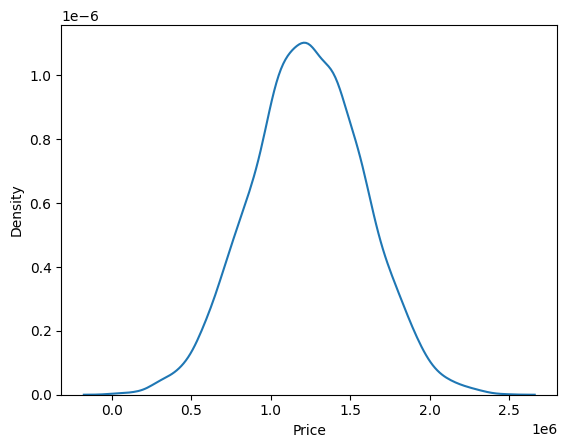

In [39]:
sns.kdeplot(df["Price"])

### Shows how income affects house price.

<Axes: xlabel='Avg. Area Income', ylabel='Price'>

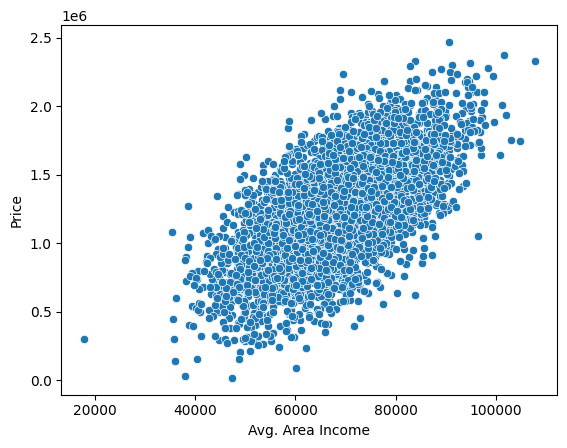

In [40]:
sns.scatterplot(x="Avg. Area Income", y="Price", data=df)

In [41]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

### Checks whether older houses are cheaper or not.

<Axes: xlabel='Avg. Area House Age', ylabel='Price'>

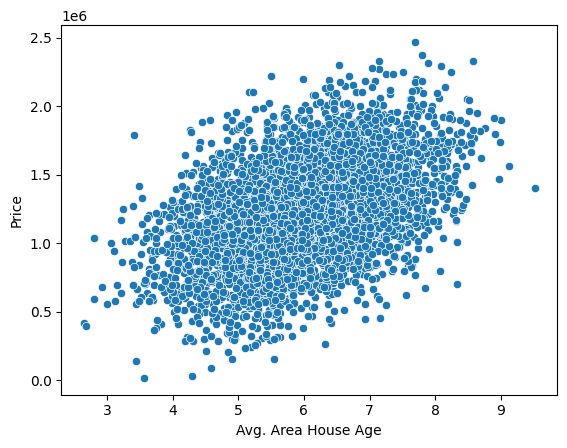

In [42]:
sns.scatterplot(x="Avg. Area House Age", y="Price", data=df)

### Shows how the number of rooms impacts price.

<Axes: xlabel='Avg. Area Number of Rooms', ylabel='Price'>

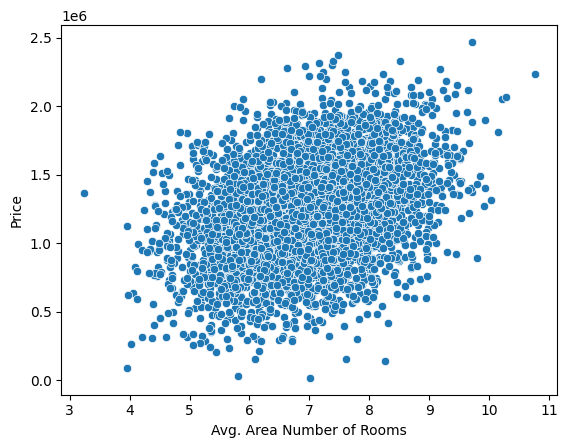

In [43]:
sns.scatterplot(x="Avg. Area Number of Rooms", y="Price", data=df)

### Gives a quick overall relationship between numeric columns.

<Axes: >

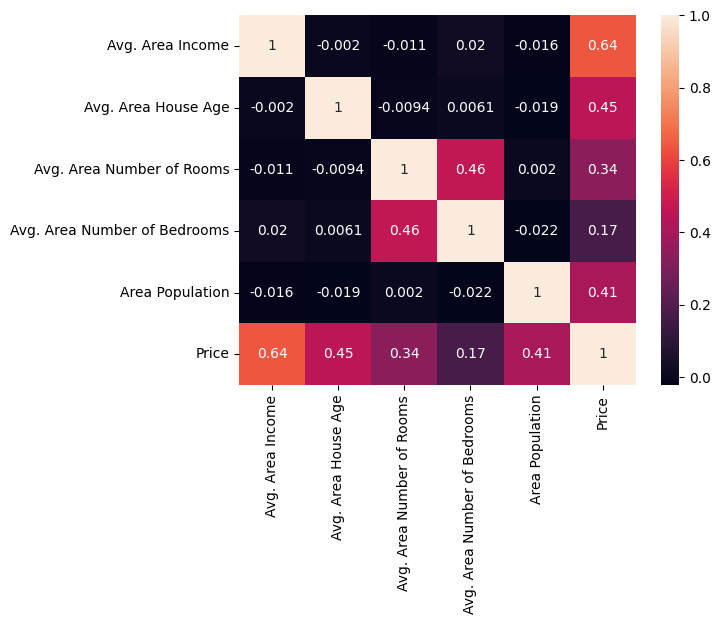

In [44]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### The two columns which are `Address` and `Avg. Area Number of Bedrooms` are of no use so we can remove it from our dataset.

In [45]:
df = df.drop(["Address", "Avg. Area Number of Bedrooms"], axis=1)

### Now we have to predict the `Price` of the house so this is the time when we split our data into X and y features.

In [46]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Area Population', 'Price'],
      dtype='object')

In [47]:
X = df.drop("Price", axis=1)
y = df["Price"]

### We split the data into training and testing sets, with 80% for training and 20% for testing.
### we will import train_test_split from sklearn.model_selection

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Create a Decision Tree Regressor `from sklearn.tree` and then train it using your training data (X_train, y_train).

### Use your trained model to predict the target values for the unseen test data (X_test).

In [53]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

### Check how well your model predicts by calculating the R² score from sklearn.metrices — it shows how much of the target’s variation is explained by your model.”

In [54]:
y_pred = model.predict(X_test)

Let's get some best parameters for our model and let's check what is the accuracy we are getting for our model for this we will use `RandomizedSearchCV` from `sklearn.model_selection`.

In [55]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7464222609184838

In [57]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [58]:
import joblib

In [59]:
joblib.dump(model, 'decision_tree_regressor_model.joblib')
joblib.dump(X_train.columns, 'model_features.joblib')
print("Model and feature columns saved successfully.")

Model and feature columns saved successfully.
